##INTRODUCTION :

This analysis explores the relationship between Bitcoin market sentiment (Fear/Greed) and trader behavior on Hyperliquid. The goal is to understand how sentiment impacts trading performance and derive actionable strategies.

In [1]:
# Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [37]:
sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [39]:
trades

,Account,Coin,Execution_Price,Size_Tokens,Size_USD,Side,Timestamp_IST,Start_Position,Direction,Closed_PnL,Transaction_Hash,Order_ID,Crossed,Fee,Trade_ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,2025-04-25 15:35:00,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12,2025-04-25
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,2025-04-25 15:35:00,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12,2025-04-25
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,2025-04-25 15:35:00,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12,2025-04-25
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,2025-04-25 15:35:00,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12,2025-04-25


In [5]:
print(sentiment.columns)


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [17]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [41]:
# Cleaning column names (removing spaces)
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

# making column names easier
trades.columns = trades.columns.str.replace(" ", "_")
sentiment.columns = sentiment.columns.str.replace(" ", "_")

# Checking structure
print(sentiment.shape)
print(trades.shape)

# Checking missing values
print("Sentiment missing:\n", sentiment.isnull().sum())
print("Trades missing:\n", trades.isnull().sum())

# Droping duplicates
sentiment.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)

# Filling or handling missing values 
sentiment.fillna(method='ffill', inplace=True)
trades.fillna(0, inplace=True)

(2644, 4)
(211224, 17)
Sentiment missing:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Trades missing:
 Account             0
Coin                0
Execution_Price     0
Size_Tokens         0
Size_USD            0
Side                0
Timestamp_IST       0
Start_Position      0
Direction           0
Closed_PnL          0
Transaction_Hash    0
Order_ID            0
Crossed             0
Fee                 0
Trade_ID            0
Timestamp           0
date                0
dtype: int64


C:\Users\mugal\AppData\Local\Temp\ipykernel_1528\3585514028.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sentiment.fillna(method='ffill', inplace=True)


In [43]:
# Convert sentiment date
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Convert trades timestamp (DD-MM-YYYY format)
trades['Timestamp_IST'] = pd.to_datetime(
    trades['Timestamp_IST'],
    dayfirst=True,
    errors='coerce'
)

# Create common date column
trades['date'] = trades['Timestamp_IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

In [45]:
# Merging Data
merged = pd.merge(trades, sentiment, on='date', how='left')

print(merged.head())

                                      Account  Coin  Execution_Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size_Tokens  Size_USD Side       Timestamp_IST  Start_Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy   

   Closed_PnL                                   Transaction_Hash     Order_ID  \
0         0

In [47]:
# Feature Engineering

# Win/Loss
merged['win'] = merged['Closed_PnL'] > 0

# Daily PnL per account
daily_pnl = merged.groupby(['date','Account'])['Closed_PnL'].sum().reset_index()

# Trade count
trade_count = merged.groupby('date').size()

# Long vs Short
long_short = merged.groupby(['classification','Side']).size()

In [59]:
# Avg trade size
avg_trade_size = merged.groupby('classification')['Size_USD'].mean()

# Trades per day
trades_per_day = merged.groupby(['date','classification']).size()

# Long/Short ratio
long_short_ratio = merged.groupby(['classification','Side']).size().unstack()

In [49]:
# Analysis

# PnL vs sentiment
pnl_sentiment = merged.groupby('classification')['Closed_PnL'].mean()
print(pnl_sentiment)

# Win rate
win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

# Trade frequency
trade_freq = merged.groupby('classification').size()
print(trade_freq)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed_PnL, dtype: float64
classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64
classification
Extreme Fear     21400
Extreme Greed    39992
Fear             61837
Greed            50303
Neutral          37686
dtype: int64


Average PnL is higher during Greed periods, indicating increased profitability but also higher risk.

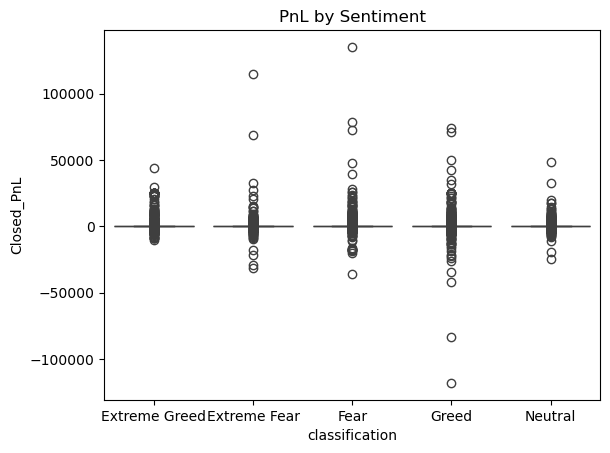

In [51]:
# VISUALIZATION
sns.boxplot(x='classification', y='Closed_PnL', data=merged)
plt.title("PnL by Sentiment")
plt.show()

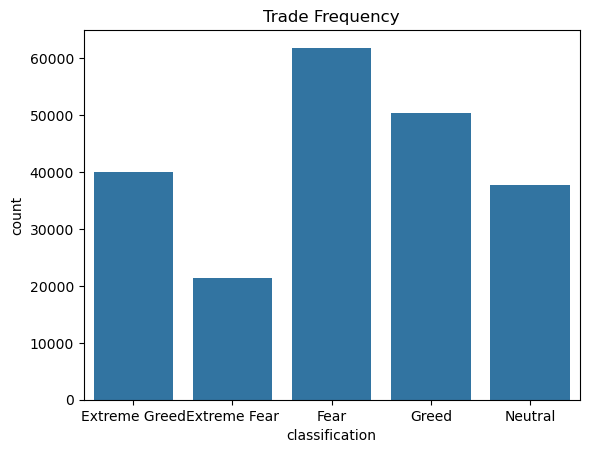

In [53]:
sns.countplot(x='classification', data=merged)
plt.title("Trade Frequency")
plt.show()

In [69]:
# Segmentation

# Frequent traders
freq = merged['Account'].value_counts()

# Profit per trader
profit = merged.groupby('Account')['Closed_PnL'].sum()

# leverage segmentation
if 'leverage' in merged.columns:
    merged['lev_group'] = np.where(
        merged['leverage'] > merged['leverage'].median(),
        'High','Low'
    )

In [71]:
print(merged.describe())

       Execution_Price   Size_Tokens      Size_USD  \
count    211224.000000  2.112240e+05  2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   
min           0.000005  8.740000e-07  0.000000e+00   
25%           4.854700  2.940000e+00  1.937900e+02   
50%          18.280000  3.200000e+01  5.970450e+02   
75%         101.580000  1.879025e+02  2.058960e+03   
max      109004.000000  1.582244e+07  3.921431e+06   
std       29447.654868  1.042729e+05  3.657514e+04   

                       Timestamp_IST  Start_Position     Closed_PnL  \
count                         211224    2.112240e+05  211224.000000   
mean   2025-01-31 12:04:22.915009792   -2.994625e+04      48.749001   
min              2023-05-01 01:06:00   -1.433463e+07 -117990.104100   
25%              2024-12-31 21:00:45   -3.762311e+02       0.000000   
50%              2025-02-24 18:55:00    8.472793e+01       0.000000   
75%              2025-04-02 18:22:00    9.337278e+03       5.792797   
max             

##Section: Bonus – Trader Segmentation

In [73]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [75]:
# Features for clustering
cluster_data = merged[['Closed_PnL', 'Size_USD']].dropna()

In [77]:
cluster_data

,Closed_PnL,Size_USD
0,0.0000,7872.16
1,0.0000,127.68
2,0.0000,1150.63
3,0.0000,1142.04
4,0.0000,69.75
...,...,...
211219,-20.2566,420.80
211220,-112.5773,2338.63
211221,-22.4402,466.16
211222,-190.7894,3963.38


In [79]:
# Scaling Data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

In [81]:
# Applying KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

cluster_data['cluster'] = clusters

In [83]:
merged.loc[cluster_data.index, 'cluster'] = cluster_data['cluster']

In [85]:
# Analyzing clusters

cluster_summary = merged.groupby('cluster')[['Closed_PnL','Size_USD']].mean()
print(cluster_summary)

           Closed_PnL       Size_USD
cluster                             
0.0         36.529385    4904.091370
1.0      29607.373871  137996.768333
2.0        621.620572  873252.657771


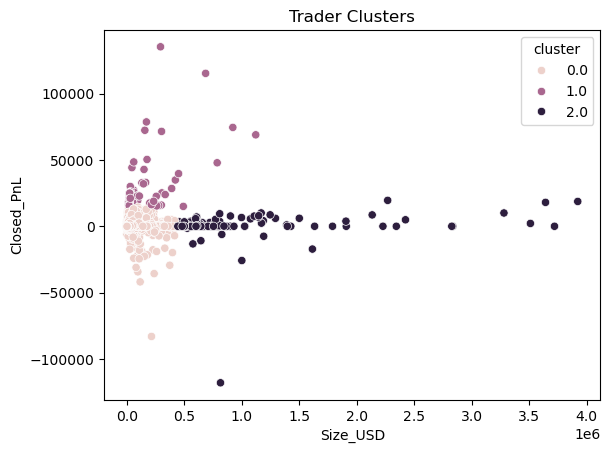

In [87]:
# Plot

import seaborn as sns

sns.scatterplot(x='Size_USD', y='Closed_PnL', hue='cluster', data=merged)
plt.title("Trader Clusters")
plt.show()

Insights :

Traders exhibit higher risk-taking behavior during Greed periods, reflected in larger trade sizes and higher PnL variability
Fear periods show unstable performance and higher downside volatility, indicating risk-averse but uncertain behavior
Trade frequency increases during strong sentiment phases, showing reactive trading patterns
Performance varies significantly across traders, suggesting the importance of segmentation

Strategy :

During Fear periods → reduce position size and leverage to minimize losses
During Greed periods → avoid overtrading and maintain disciplined entry strategies
High-frequency traders should adopt stricter risk management rules
Segment traders and apply customized strategies instead of one-size-fits-all

Bonus Insights :
Traders can be grouped into distinct clusters based on their behavior and performance
One cluster represents high-risk, high-reward traders with large position sizes
Another cluster represents conservative traders with smaller trades and stable outcomes
This segmentation helps identify different trading strategies and risk profiles

Bonus Strategy :
High-risk cluster → implement strict risk controls
Conservative cluster → increase position size gradually
Target different strategies for different trader types

## Conclusion

This analysis shows that market sentiment strongly influences trader behavior and performance. By adapting strategies based on sentiment and trader type, more consistent results can be achieved.